In [27]:
import pandas as pd
import numpy as np

data_dir = '../data'

train_df = pd.read_csv(f'{data_dir}/train.txt',sep=';', names=['text', 'emotions'])
test_df = pd.read_csv(f'{data_dir}/test.txt',sep=';', names=['text', 'emotions'])
val_df = pd.read_csv(f'{data_dir}/val.txt',sep=';', names=['text', 'emotions'])

train_df

,text,emotions
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [28]:
train_df['emotions'].unique()

<StringArray>
['sadness', 'anger', 'love', 'surprise', 'fear', 'joy']
Length: 6, dtype: str

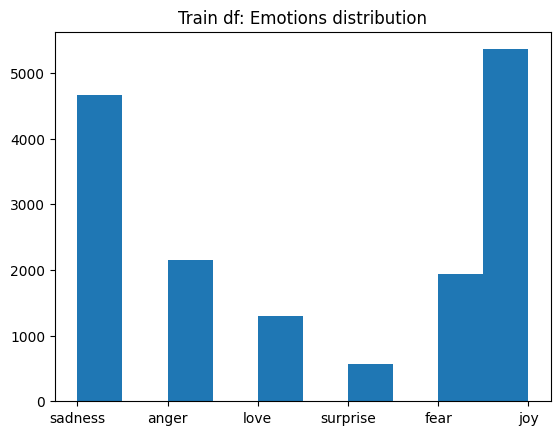

In [29]:
import matplotlib.pyplot as plt

plt.hist(train_df['emotions'])
plt.title("Train df: Emotions distribution")
plt.show()

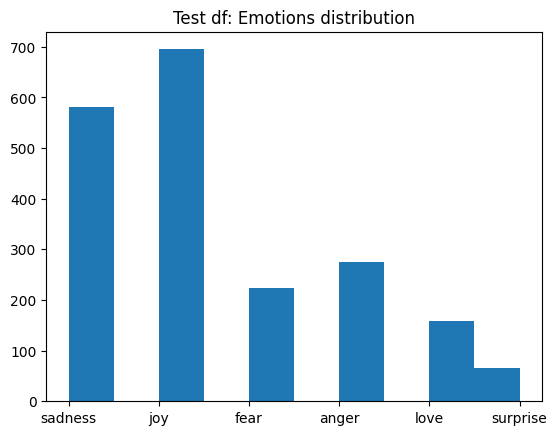

In [30]:
plt.hist(test_df['emotions'])
plt.title("Test df: Emotions distribution")
plt.show()

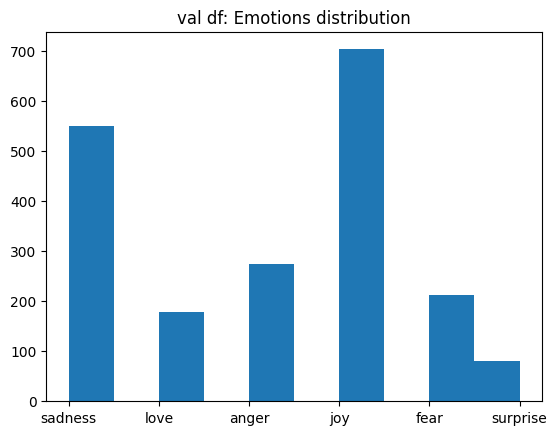

In [31]:
plt.hist(val_df['emotions'])
plt.title("val df: Emotions distribution")
plt.show()

In [32]:
X_train = train_df.drop(['emotions'], axis=1)
y_train = train_df['emotions']

X_test = test_df.drop(['emotions'], axis=1)
y_test = test_df['emotions']

X_val = test_df.drop(['emotions'], axis=1)
y_val = test_df['emotions']

In [33]:
X_train

,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy
...,...
15995,i just had a very brief time in the beanbag an...
15996,i am now turning and i feel pathetic that i am...
15997,i feel strong and good overall
15998,i feel like this was such a rude comment and i...


In [34]:
y_train

0        sadness
1        sadness
2          anger
3           love
4          anger
          ...   
15995    sadness
15996    sadness
15997        joy
15998      anger
15999    sadness
Name: emotions, Length: 16000, dtype: str

In [35]:
emotion_map = {
    'sadness': 0,
    'anger': 1,
    'love': 2,
    'surprise': 3,
    'fear': 4,
    'joy': 5
}

y_train_encoded = y_train.map(emotion_map)
y_test_encoded = y_test.map(emotion_map)

y_train_encoded

0        0
1        0
2        1
3        2
4        1
        ..
15995    0
15996    0
15997    5
15998    1
15999    0
Name: emotions, Length: 16000, dtype: int64

Word count per sentence:
count    16000.0
mean        19.2
std         11.0
min          2.0
25%         11.0
50%         17.0
75%         25.0
max         66.0


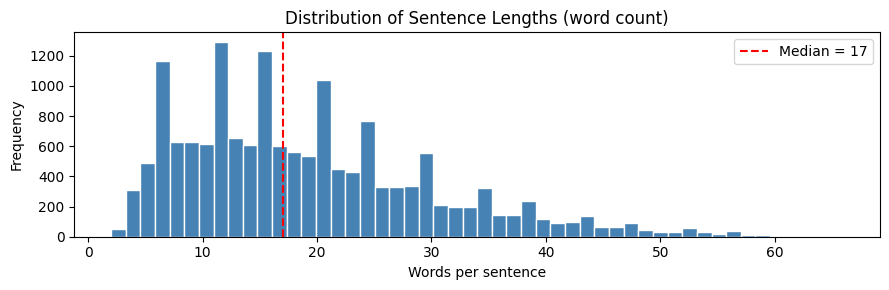

In [36]:
word_count_df = pd.DataFrame()

word_count_df['word_count'] = X_train['text'].str.split().str.len()

print('Word count per sentence:')
print(word_count_df['word_count'].describe().round(1).to_string())

plt.figure(figsize=(9, 3))
plt.hist(word_count_df['word_count'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(word_count_df['word_count'].median(), color='red', linestyle='--',
            label=f'Median = {word_count_df["word_count"].median():.0f}')
plt.title('Distribution of Sentence Lengths (word count)')
plt.xlabel('Words per sentence')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
X_train

,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy
...,...
15995,i just had a very brief time in the beanbag an...
15996,i am now turning and i feel pathetic that i am...
15997,i feel strong and good overall
15998,i feel like this was such a rude comment and i...


# Just checking tokenizer here

In [38]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

texts = X_train['text'].tolist()

encodings = tokenizer(
    texts, 
    padding = True,
    truncation = True,
    return_tensors="pt"
)

encodings.keys()

KeysView({'input_ids': tensor([[  101,  1045,  2134,  ...,     0,     0,     0],
        [  101,  1045,  2064,  ...,     0,     0,     0],
        [  101, 10047,  9775,  ...,     0,     0,     0],
        ...,
        [  101,  1045,  2514,  ...,     0,     0,     0],
        [  101,  1045,  2514,  ...,     0,     0,     0],
        [  101,  1045,  2113,  ...,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])})

In [39]:
len(encodings['input_ids'])

16000

# creating dataset class

In [40]:
import torch
from torch.utils.data import Dataset

class Dataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(texts, padding = True, truncation = True)
        self.labels = labels
        self.vocab_size = tokenizer.vocab_size
    def __getitem__(self, item):
        # data = {k: torch.tensor(v[item]) for k, v in self.encodings.items()}
        # data['labels'] = torch.tensor(self.labels[item])
        # return data
        return(
            torch.tensor(self.encodings['input_ids'][item]),
            torch.tensor(self.labels[item])
        )
    def __len__(self):
        return len(self.labels)
    
train_ds = Dataset(X_train['text'].tolist(), y_train_encoded.tolist(), tokenizer=tokenizer)
test_ds = Dataset(X_test['text'].tolist(), y_test_encoded.tolist(), tokenizer)

vocab_size = train_ds.vocab_size
vocab_size

30522

In [41]:
import torch.nn as nn
from torch.utils.data import DataLoader

class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim=embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        _, h = self.rnn(x)
        output = self.fc(h[-1])
        return output
    
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

In [42]:
model = RNNClassifier(train_ds.vocab_size, embed_dim=128, hidden_dim=256, num_classes=len(set(y_train)))

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def eval(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in loader:
            X = X
            y = y
            preds = model(X).argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return (correct / total) * 100

def train(model, train_loader, test_loader, loss_fn, optimizer, epochs=5):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            optimizer.zero_grad()
            
            y_hat = model(x)
            loss = loss_fn(y_hat, y)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        acc = eval(model, test_loader)
        print(f'Epoch: {epoch} - loss: {total_loss} - acc: {acc}')

In [43]:
# train(model, train_loader, test_loader, loss_fn, optimizer, 1)

# Bert training


In [44]:
len(y_train_encoded.unique())

6

In [45]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = 'bert-base-uncased'

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels = len(y_train_encoded.unique())
)

train_texts = X_train['text'].tolist()
test_texts = X_test['text'].tolist()

train_encodings = tokenizer(
    train_texts, 
    padding = True,
    truncation = True,
    return_tensors="pt"
)

test_encodings = tokenizer(
    test_texts, 
    padding = True,
    truncation = True,
    return_tensors="pt"
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4239.55it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

In [46]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
        
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item
    
    def __len__(self):
        return len(self.labels)

In [47]:
train_ds = Dataset(train_encodings, y_train_encoded.tolist())
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

test_ds = Dataset(test_encodings, y_test_encoded.tolist())
test_loader = DataLoader(test_ds, batch_size=16)

In [48]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

def evalBert(model, test_loader):
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch["labels"]

            # forward pass
            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"]
            )
            preds = outputs.logits.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return (correct / total) * 100

def trainBert(model, optimizer, train_loader, test_loader, epochs=5):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            
            outputs = model(**batch)
            loss = outputs.loss
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        acc = evalBert(model, test_loader=test_loader)
        print(f'Epoch: {epoch} - loss: {total_loss} - acc: {acc}')

In [49]:
# trainBert(model, optimizer, train_loader, test_loader, 3)

In [52]:
import os
from transformers import BertForSequenceClassification, AutoTokenizer
import torch
import os

root_path = os.getcwd()

print(root_path)

model = BertForSequenceClassification.from_pretrained(f'{root_path}/../models/model')
tokenizer = AutoTokenizer.from_pretrained(f'{root_path}/..//models/tokenizer')

d:\Study\Projects\emotions-recognition\notebooks


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3679.76it/s]


              precision    recall  f1-score   support

           0       0.96      0.98      0.97       581
           1       0.97      0.89      0.93       275
           2       0.76      0.96      0.85       159
           3       0.95      0.59      0.73        66
           4       0.86      0.97      0.91       224
           5       0.97      0.93      0.95       695

    accuracy                           0.93      2000
   macro avg       0.91      0.89      0.89      2000
weighted avg       0.94      0.93      0.93      2000



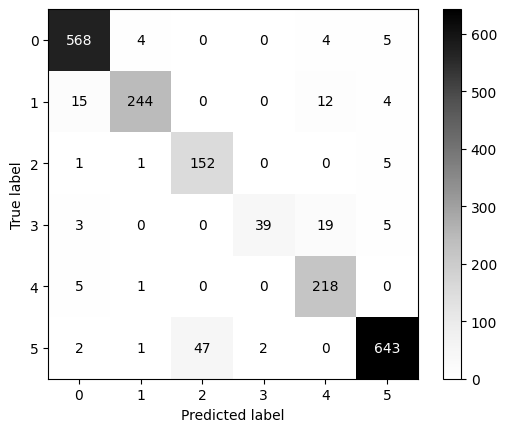

In [59]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

encodings = tokenizer(
    X_test["text"].tolist(),
    padding=True,
    truncation=True,
    return_tensors="pt"
)

with torch.no_grad():
    model.eval()
    output = model(**encodings)
logits = output.logits 
probs = torch.softmax(logits, dim=1)

pred = torch.argmax(probs, dim=1)
print(classification_report(y_test_encoded, pred))

cm = confusion_matrix(y_test_encoded, pred)
cm_disp = ConfusionMatrixDisplay(confusion_matrix=cm)
cm_disp.plot(values_format='d', cmap='Greys')
plt.show()